In [2]:
#Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor



## Load Dataset

In [6]:

filepath = "/content/House_Pricing.csv"
df_Houseprice = pd.read_csv(filepath)
df_Houseprice.head()


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


## Dataset Exploration

In [ ]:

print("Shape:", df_Houseprice.shape)
display(df_Houseprice.head())
display(df_Houseprice.tail())
display(df_Houseprice.info())
display(df_Houseprice.describe(include='all'))


## Missing Values

In [8]:

print(df_Houseprice.isnull().sum())

if 'No of Times Visited' in df_Houseprice.columns:
    df_Houseprice.drop(columns=['No of Times Visited'], inplace=True)

print(df_Houseprice.isnull().sum())


ID                                               0
Date House was Sold                              0
Sale Price                                       4
No of Bedrooms                                   0
No of Bathrooms                                  4
Flat Area (in Sqft)                              9
Lot Area (in Sqft)                               9
No of Floors                                     0
Waterfront View                                  0
No of Times Visited                          19489
Condition of the House                           0
Overall Grade                                    0
Area of the House from Basement (in Sqft)        3
Basement Area (in Sqft)                          0
Age of House (in Years)                          0
Renovated Year                                   0
Zipcode                                          1
Latitude                                         1
Longitude                                        1
Living Area after Renovation (i

## Handle Missing Values

In [9]:

numeric_cols = df_Houseprice.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df_Houseprice[col] = df_Houseprice[col].fillna(df_Houseprice[col].median())

categorical_cols = df_Houseprice.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    df_Houseprice[col] = df_Houseprice[col].fillna(df_Houseprice[col].mode()[0])

print(df_Houseprice.isnull().sum().sum())


0


## Remove Duplicates

In [11]:

print("Duplicates:", df_Houseprice.duplicated().sum())
df = df_Houseprice.drop_duplicates()
print(df.shape)


Duplicates: 0
(21613, 20)


## Exploratory Data Analysis

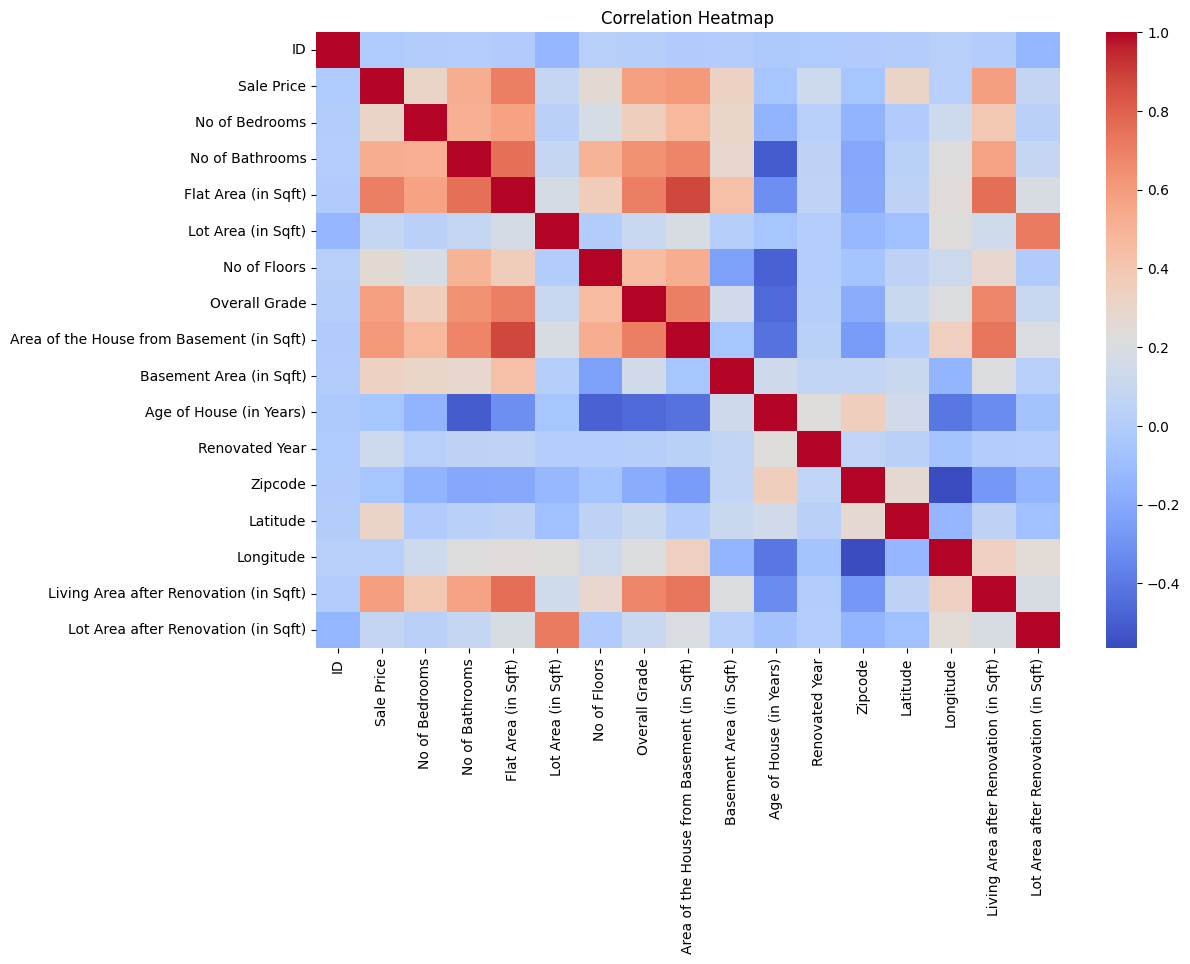

In [12]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


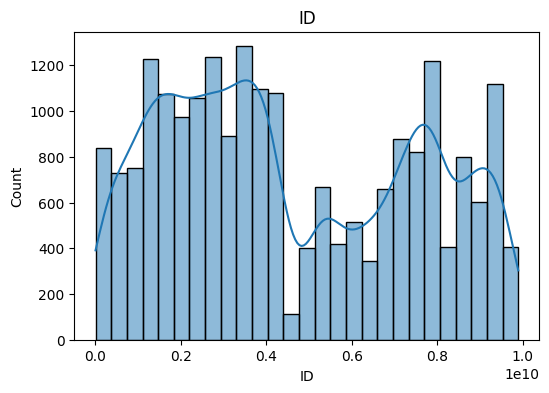

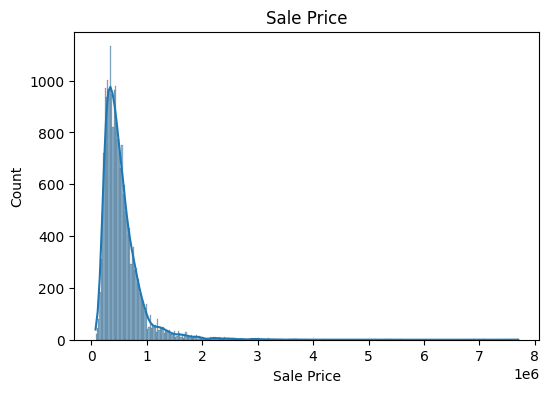

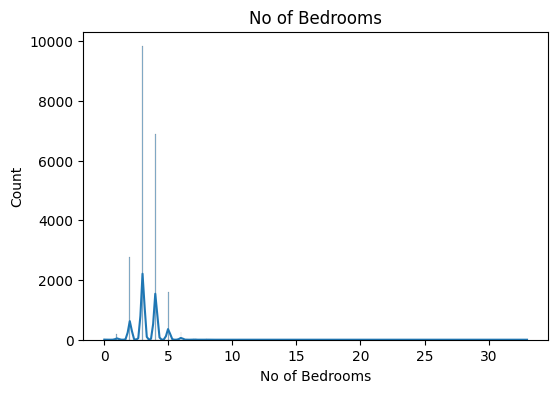

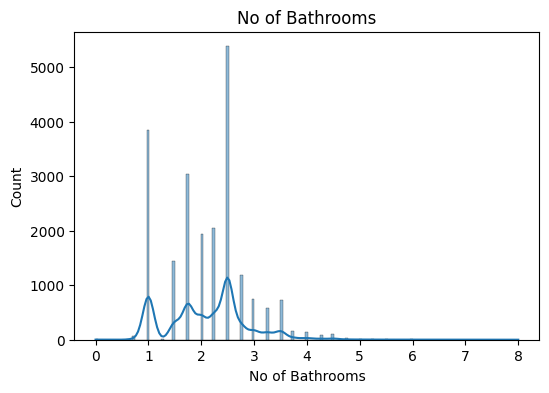

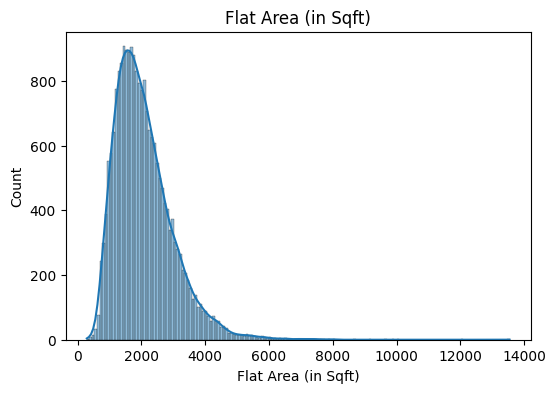

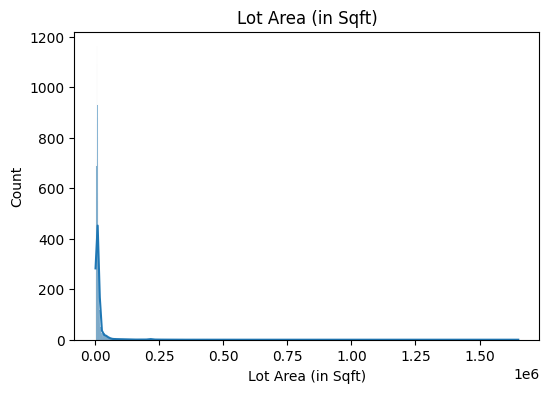

In [13]:

num_cols = df_Houseprice.select_dtypes(include=np.number).columns

for col in num_cols[:6]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


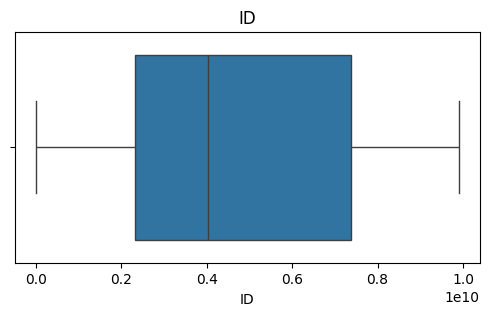

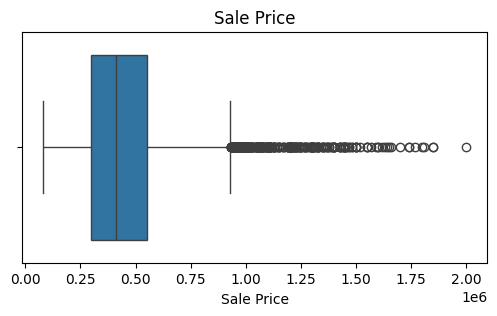

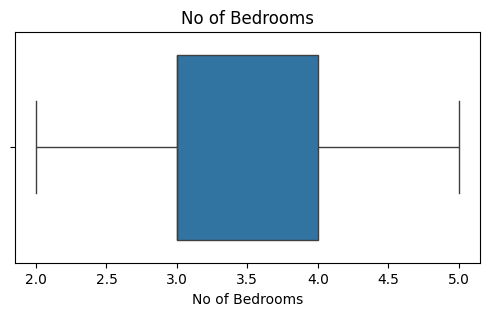

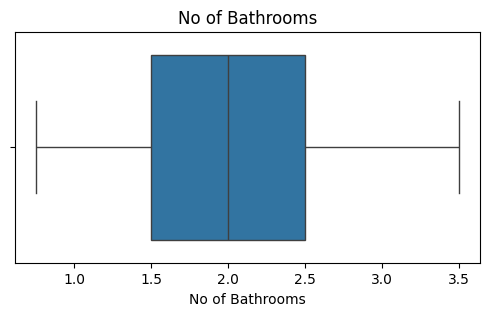

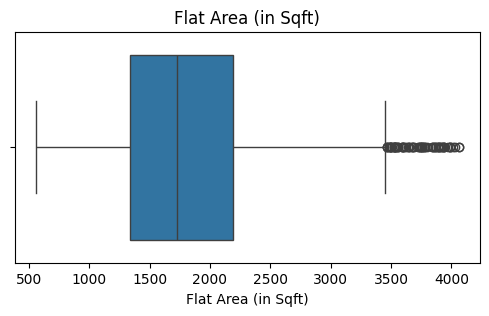

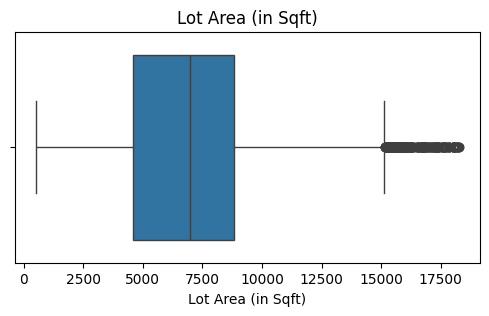

In [19]:

for col in num_cols[:6]:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


## Outlier Treatment using IQR

In [14]:

def remove_outliers_iqr(data, columns):
    data = data.copy()
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5*iqr
        upper = q3 + 1.5*iqr
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

outlier_cols = [c for c in num_cols if c != 'Sale Price']
df = remove_outliers_iqr(df, outlier_cols)
print(df.shape)


(15103, 20)


## Split Features and Target

In [18]:
y = df_Houseprice['Sale Price']
X = df_Houseprice.drop(columns = ['Sale Price'])

X_test, X_train, y_test, y_train = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42 )

## Build Models

In [20]:

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model','MAE','MSE','RMSE','R2 Score']
)

results_df.sort_values('R2 Score', ascending=False)


ValueError: could not convert string to float: '14 October 2017'

## Best Model

In [ ]:

best_model_name = results_df.sort_values(
    'R2 Score',
    ascending=False
).iloc[0]['Model']

best_model = models[best_model_name]

pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(best_model_name)
plt.show()


## Feature Importance (Random Forest)

In [ ]:

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'Feature':feature_names,
    'Importance':rf.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance.head(20))

plt.figure(figsize=(8,6))
plt.barh(importance['Feature'][:15], importance['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()


## Save Model

In [ ]:

joblib.dump(best_model,'best_house_price_model.pkl')
joblib.dump(preprocessor,'preprocessor.pkl')

print("Model saved successfully.")


## Predict New Data

In [ ]:

sample = X.iloc[[0]]
sample_processed = preprocessor.transform(sample)
prediction = best_model.predict(sample_processed)
print("Predicted Sale Price:", prediction[0])
